In [ ]:
# Heart Disease Prediction using Decision Tree Algorithm

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
df = pd.read_csv("heart.csv")

In [ ]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [ ]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [ ]:
#Variable identification
#Dependent Variable - Target
#Inependent Variable - [age,sex,cp,trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal]

In [ ]:
to_rename = {'age' : 'Age','sex' : 'Sex','cp' : 'Chest Pain','trestbps' : 'BPS','chol' : 'Cholesterol',
             'fbs' : 'FBS','restecg' : 'RestECG','thalach' : 'Thalach','exang' : 'EIA','oldpeak' : 'Oldpeak',
             'slope' : 'Slope','ca' : 'CA','thal' : 'Thal','target' : 'Target'}
df.rename(columns = to_rename, inplace = True)

In [ ]:
df

,Age,Sex,Chest Pain,BPS,Cholesterol,FBS,RestECG,Thalach,EIA,Oldpeak,Slope,CA,Thal,Target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [ ]:
#EXPLORATORY DATA ANALYSIS

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          303 non-null    int64  
 1   Sex          303 non-null    int64  
 2   Chest Pain   303 non-null    int64  
 3   BPS          303 non-null    int64  
 4   Cholesterol  303 non-null    int64  
 5   FBS          303 non-null    int64  
 6   RestECG      303 non-null    int64  
 7   Thalach      303 non-null    int64  
 8   EIA          303 non-null    int64  
 9   Oldpeak      303 non-null    float64
 10  Slope        303 non-null    int64  
 11  CA           303 non-null    int64  
 12  Thal         303 non-null    int64  
 13  Target       303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [ ]:
#Univariate Analysis

<Axes: xlabel='Age', ylabel='count'>

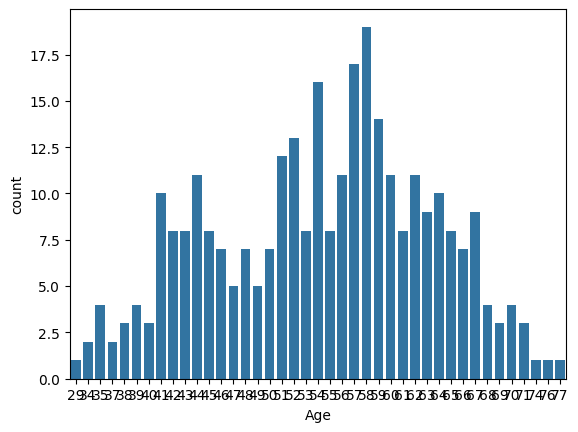

In [ ]:
sns.countplot(x='Age', data=df)

<Axes: xlabel='Sex', ylabel='count'>

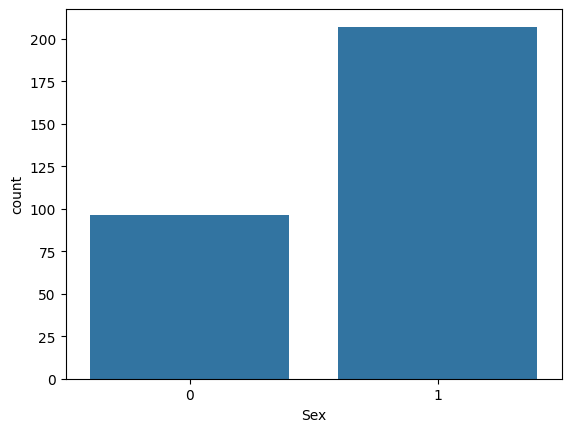

In [ ]:
sns.countplot(x='Sex', data=df)

<Axes: xlabel='Chest Pain', ylabel='count'>

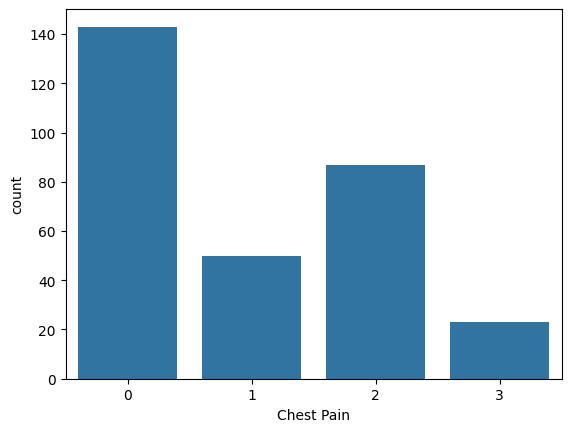

In [ ]:
sns.countplot(x='Chest Pain', data=df)

<Axes: xlabel='BPS', ylabel='count'>

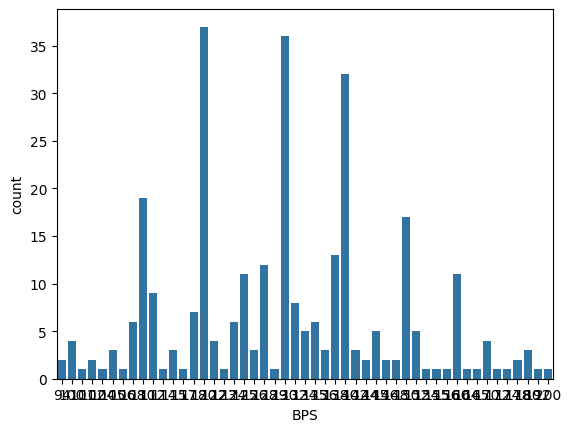

In [ ]:
sns.countplot(x='BPS', data=df)

<ipython-input-16-7daec3e76222>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["Cholesterol"], color='c')


<Axes: xlabel='Cholesterol', ylabel='Density'>

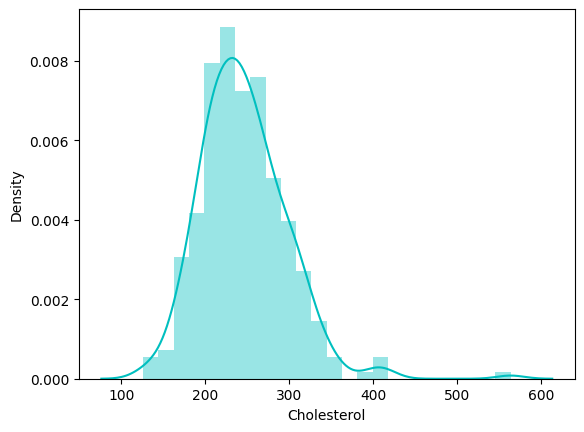

In [ ]:
sns.distplot(df["Cholesterol"], color='c')

<Axes: ylabel='count'>

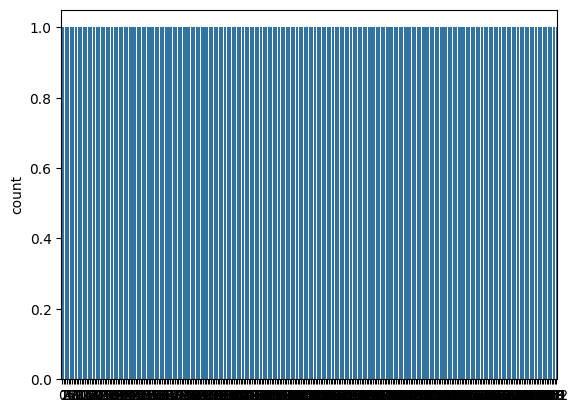

In [ ]:
sns.countplot(df['FBS'])

In [ ]:
#Bivariate Analysis

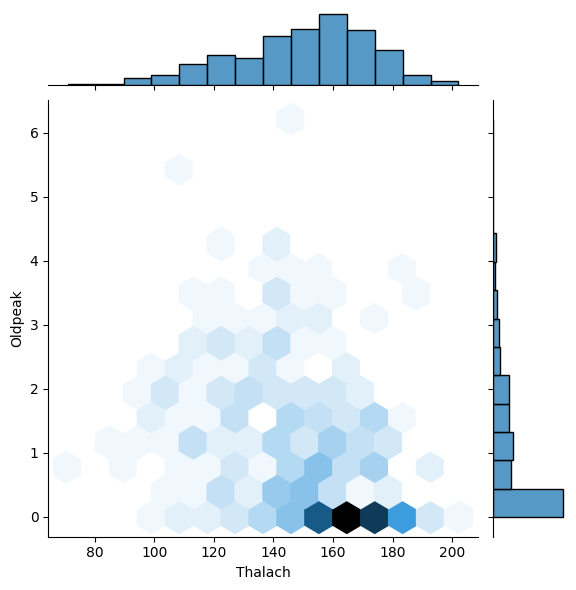

In [ ]:
sns.jointplot(x = 'Thalach', y = 'Oldpeak', data= df, kind ='hex')

In [ ]:
df1 = df[['Sex','BPS','Cholesterol','Thalach', 'Oldpeak']]
df1

,Sex,BPS,Cholesterol,Thalach,Oldpeak
0,1,145,233,150,2.3
1,1,130,250,187,3.5
2,0,130,204,172,1.4
3,1,120,236,178,0.8
4,0,120,354,163,0.6
...,...,...,...,...,...
298,0,140,241,123,0.2
299,1,110,264,132,1.2
300,1,144,193,141,3.4
301,1,130,131,115,1.2


/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When 

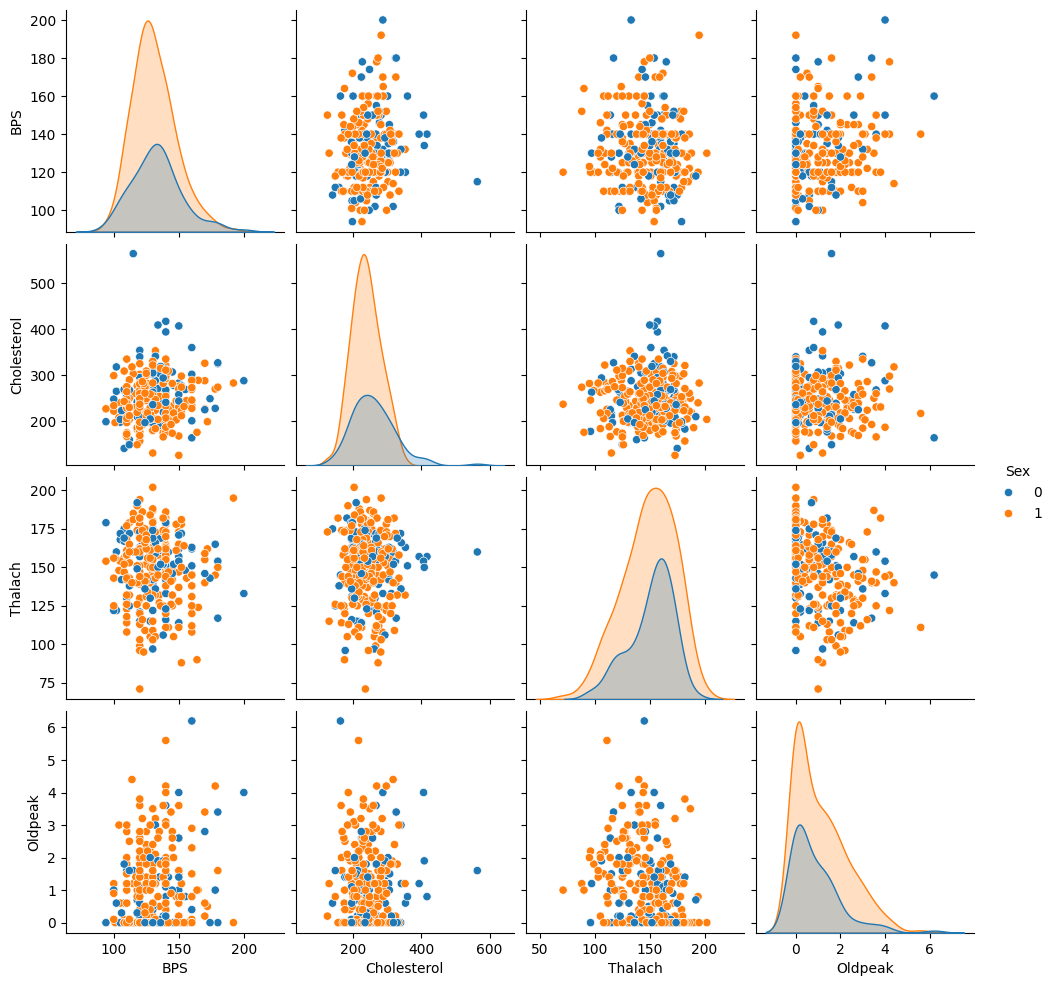

In [ ]:
g = sns.pairplot(df1, hue='Sex')

In [ ]:
#Model fitting

In [ ]:
df.describe()

,Age,Sex,Chest Pain,BPS,Cholesterol,FBS,RestECG,Thalach,EIA,Oldpeak,Slope,CA,Thal,Target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [ ]:
x = df.iloc[:,:-1].values
y = df.iloc[:,-1].values

In [ ]:
from sklearn.model_selection import train_test_split #importing split function

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 43)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
#Calculating GINI Index
#GINI Index = (P^2+Q^2), where P= Probability of Success
                            #  Q= Probability of Failure
#bydefault, the criteria is GINI and the classifier is best

In [ ]:
DTC = DecisionTreeClassifier()
DTC = DTC.fit(x_train,y_train)

In [ ]:
y_pred = DTC.predict(x_test)

In [ ]:
y_pred

array([0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1,
       0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0,
       0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1])

In [ ]:
#Model Accuracy

In [ ]:
from sklearn import metrics

In [ ]:
from sklearn.metrics import confusion_matrix
CM = confusion_matrix(y_test,y_pred)
CM

array([[28, 13],
       [ 6, 44]])

In [ ]:
metrics.accuracy_score(y_test, y_pred)

0.7912087912087912

In [ ]:
print("Accuracy :", round(metrics.accuracy_score(y_test, y_pred)*100,2),"%")

Accuracy : 79.12 %


In [ ]:
y_pred=DTC.predict(x)
Rsquared = round(metrics.r2_score(y,y_pred),4)
Rsquared

0.7472

In [ ]:
MSE = round(metrics.mean_squared_error(y,y_pred),4)
MSE

0.0627

In [ ]:
RMSE = round(np.sqrt(MSE),4)
RMSE

0.2504